In [ ]:
from google.colab import files

upload = files.upload()


Saving Raw_data(Road_Accident).csv to Raw_data(Road_Accident) (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv(r'Raw_data(Road_Accident).csv')

print(df.head())

       ID          State                 Date Day_of_Week Time_of_Day  \
0  165433    Connecticut  2024-02-20 05:46:20     Tuesday    19:59:02   
1  165434  Massachusetts  2024-01-09 05:08:31   Wednesday    21:28:51   
2  165435        Wyoming  2024-02-20 08:26:27    Thursday    18:04:26   
3  165436         Hawaii  2024-01-15 03:23:47      Sunday    16:51:02   
4  165437       Oklahoma  2024-02-10 10:17:29     Tuesday    14:19:19   

  Weather_Conditions Road_Conditions Light_Conditions Type_of_Road  \
0              Rainy           Muddy         Daylight       Street   
1              Sunny           Muddy         Daylight      Highway   
2              Snowy           Snowy             Dawn       Street   
3              Snowy             Icy         Daylight       Street   
4              Foggy             Icy            Night        Rural   

  Type_of_Junction  ... Num_Vehicles_Involved Num_Casualties Speed_Limit  \
0       T-Junction  ...                     2              3    

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  1610 non-null   int64  
 1   State                               1610 non-null   object 
 2   Date                                1610 non-null   object 
 3   Day_of_Week                         1610 non-null   object 
 4   Time_of_Day                         1610 non-null   object 
 5   Weather_Conditions                  1461 non-null   object 
 6   Road_Conditions                     1610 non-null   object 
 7   Light_Conditions                    1610 non-null   object 
 8   Type_of_Road                        1610 non-null   object 
 9   Type_of_Junction                    1455 non-null   object 
 10  Type_of_Accident                    1610 non-null   object 
 11  Vehicle_Type                        1610 no

In [ ]:
## Checking for missing values:
missing_info = df.isna().sum()
total_rows = len(df)
missing_percentage = (missing_info/total_rows)*100

print("Missing Values per Column:")
print(pd.concat([missing_info, missing_percentage], axis=1, keys=['Count', 'Percentage']))

Missing Values per Column:
                                    Count  Percentage
ID                                      0    0.000000
State                                   0    0.000000
Date                                    0    0.000000
Day_of_Week                             0    0.000000
Time_of_Day                             0    0.000000
Weather_Conditions                    149    9.254658
Road_Conditions                         0    0.000000
Light_Conditions                        0    0.000000
Type_of_Road                            0    0.000000
Type_of_Junction                      155    9.627329
Type_of_Accident                        0    0.000000
Vehicle_Type                            0    0.000000
Driver_Age_Group                        0    0.000000
Num_Vehicles_Involved                   0    0.000000
Num_Casualties                          0    0.000000
Speed_Limit                           153    9.503106
Distance_to_Nearest_Hospital            0    0.000000
D

In [ ]:
# Summary of unique values for categorical columns to check for "Unknown" or noisy data

categorical_cols = ['Weather_Conditions', 'Road_Conditions', 'Light_Conditions', 'Type_of_Road', 'Driver_Age_Group']
for i in categorical_cols:
    if i in df.columns:
        print(f"\nUnique values in {i}:")
        print(df[i].value_counts(dropna=False))


Unique values in Weather_Conditions:
Weather_Conditions
Rainy     313
Snowy     302
Sunny     287
Stormy    285
Foggy     274
NaN       149
Name: count, dtype: int64

Unique values in Road_Conditions:
Road_Conditions
Dry      336
Wet      330
Muddy    326
Snowy    321
Icy      297
Name: count, dtype: int64

Unique values in Light_Conditions:
Light_Conditions
Dusk        415
Daylight    407
Dawn        403
Night       385
Name: count, dtype: int64

Unique values in Type_of_Road:
Type_of_Road
Rural      336
Freeway    325
Highway    320
Urban      315
Street     314
Name: count, dtype: int64

Unique values in Driver_Age_Group:
Driver_Age_Group
Adult          420
Senior         406
Young Adult    395
Teenager       389
Name: count, dtype: int64


# **Assumptions & Uncertainty Check:**

**1. Identified Assumptions**


**A. Data Completeness:**

The raw data shows that approximately **9% to 11%** of records are missing for critical variables like **Vehicle_Speed**, **Weather_Conditions**,
and **Speed_Limit.**

We assume these missing values occur at random. For example, police were less likely to record **speed in fatal accidents,** our speed averages are artificially low.


**B. Representativeness:**

Because this is a **simulated data**, the patterns observed do not reflect real-world road safety statistics but rather a **controlled environment** designed for analysis. While the dataset is useful for identifying trends, it exhibits **artificial uniformity**, with accidents distributed almost perfectly across all states, weather conditions, and road types. This can be rarely seen in **genuine accident reports**.


**C. Variable Definitions:**

"Visibility" is recorded as a continuous number (e.g., 485.6) assumes a spatial **precision** that likely doesn't exist.

Responding officers rarely say visibility was "485.6 meters"; they say "about 500 meters." Because these measurements are taken from **distant weather stations** rather than the crash site itself.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_270/2436411074.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.values, y=missing_counts.index, palette='mako')


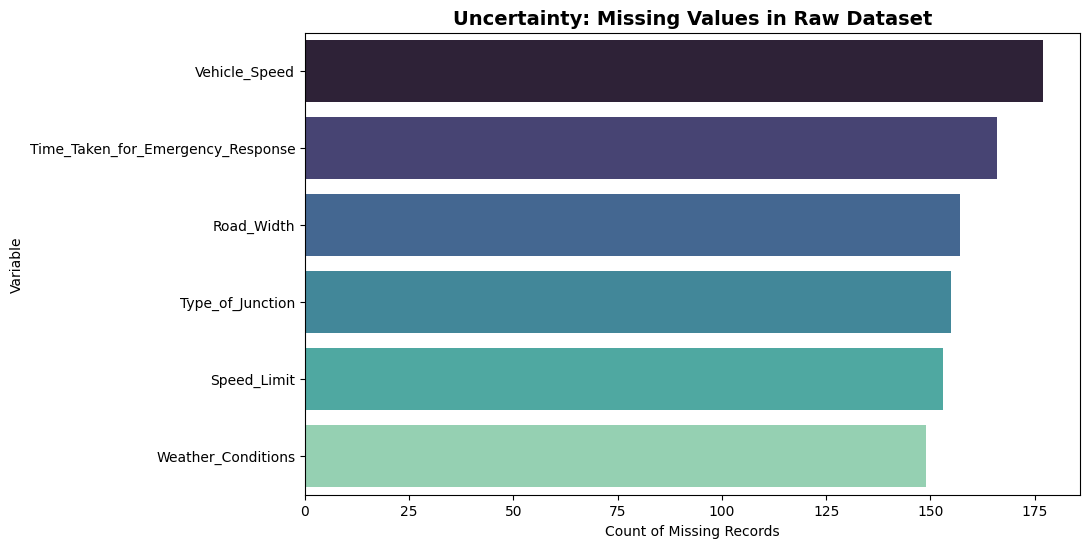

In [ ]:
# 1. Visualization of Missing Data (Uncertainty)
plt.figure(figsize=(10, 6))
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
sns.barplot(x=missing_counts.values, y=missing_counts.index, palette='mako')
plt.title('Uncertainty: Missing Values in Raw Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Count of Missing Records')
plt.ylabel('Variable')

plt.show()



/tmp/ipykernel_270/1761693369.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=speed_data, x='Type_of_Road', y='Vehicle_Speed', palette='Set2', showfliers=False)


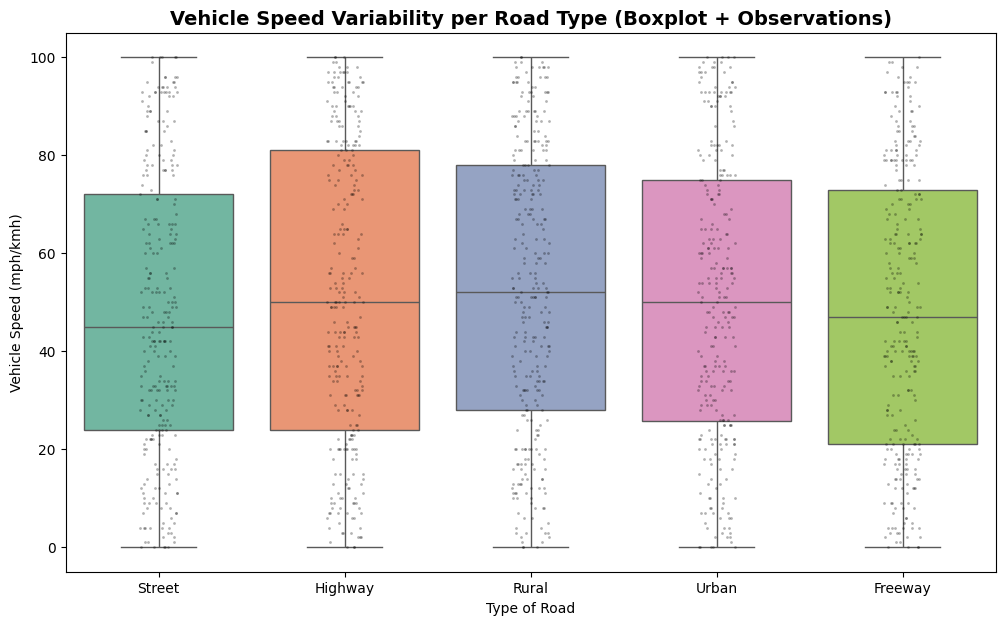

In [ ]:
## Boxplot + Stripplot (to show variability and density)

# Dropping NaNs for this specific plot
speed_data = df[['Type_of_Road', 'Vehicle_Speed']].dropna()

plt.figure(figsize=(12, 7))
sns.boxplot(data=speed_data, x='Type_of_Road', y='Vehicle_Speed', palette='Set2', showfliers=False)

sns.stripplot(data=speed_data, x='Type_of_Road', y='Vehicle_Speed', color='black', size=2, alpha=0.3, jitter=True)

plt.title('Vehicle Speed Variability per Road Type (Boxplot + Observations)', fontsize=14, fontweight='bold')
plt.ylabel('Vehicle Speed (mph/kmh)')
plt.xlabel('Type of Road')


plt.show()

**2.Revised Visualizations **

To address the issues, I have made some visuals to show **variability** rather than just averages.

1. I have made a **missing Data Chart** to explicitly show where our information is weakest (e.g., Vehicle_Speed)

2. Replaced **standard bar charts** for speed with a **Boxplot + Stripplot combo**. This shows not just the average speed, but every individual accident (the black dots), highlighting the massive overlap between road types.



/tmp/ipykernel_270/3761699695.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Weather_Conditions', y='Num_Casualties', order=weather_order, palette='Reds', ci=None)
/tmp/ipykernel_270/3761699695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Weather_Conditions', y='Num_Casualties', order=weather_order, palette='Reds', ci=None)


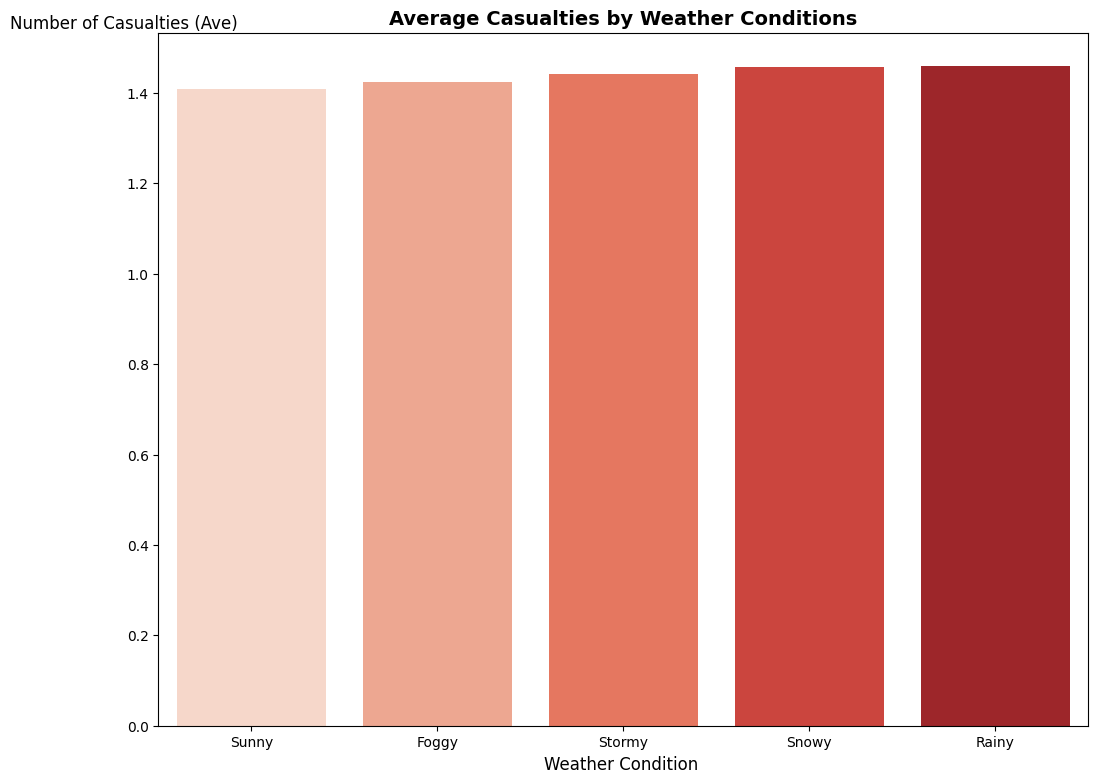

/tmp/ipykernel_270/3761699695.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Weather_Conditions', y='Num_Casualties',


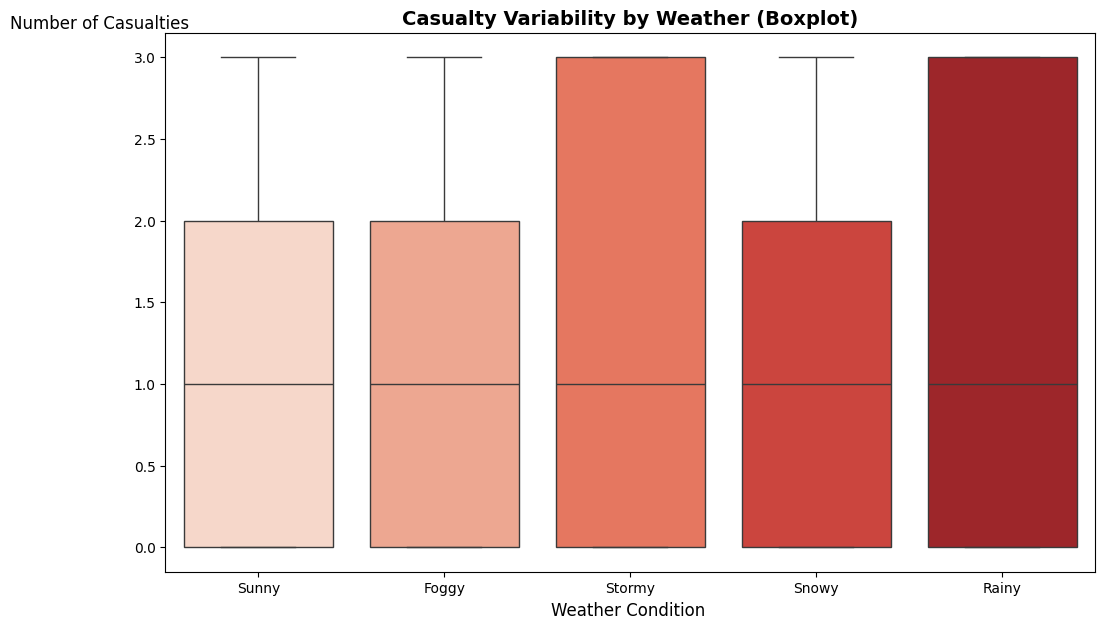

In [ ]:

weather_order = df.groupby('Weather_Conditions')['Num_Casualties'].mean().sort_values(ascending=True).index

plt.figure(figsize=(12, 9))

sns.barplot(data=df, x='Weather_Conditions', y='Num_Casualties', order=weather_order, palette='Reds', ci=None)
plt.title('Average Casualties by Weather Conditions', fontsize=14, fontweight='bold')
plt.ylabel("Number of Casualties (Ave)", rotation=0, loc='top', labelpad=-80, fontsize=12)
plt.xlabel("Weather Condition ", fontsize=12)
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Weather_Conditions', y='Num_Casualties',
            order=weather_order, palette='Reds')
plt.title('Casualty Variability by Weather (Boxplot)', fontsize=14, fontweight='bold')
plt.ylabel("Number of Casualties", rotation=0, loc='top', labelpad=-40, fontsize=12)
plt.xlabel("Weather Condition ", fontsize=12)
plt.show()

**Misleading Encoding:**

The upper graph is **misleading** because it only **shows the mean**. It suggests that **Stormy weather** is significantly more **dangerous** than **Sunny** weather, but it hides whether this is based on a few extreme accidents or a consistent trend.

The another graph I have made a **Boxplot** which is excellent for showing that casualties **vary wildly from 0 to 5 regardless of the weather**. It prevents the viewer from thinking the average is the only thing that happens.

**What could someone misunderstand from our visuals?**

1. It’s easy to look at a **bar chart** and think **"Stormy"** weather is the **deadliest** just because its **average is slightly higher**. But because we used Box Plots, you can see the truth: the data is spread out and overlaps a ton. Statistically, no single weather type is clearly worse than the others in this dataset.


2. **In the real world**, big states like **Texas** have way **more accidents** than small ones, and it **doesn't snow** as often as it shines. Because this data is split evenly across states and weather, **we can't use these charts to predict actual road safety trends.**